# Quality Control and Filtering — GSE217498

**Dataset**: GSE217498 — Mouse gastric mucosa (2 samples: 1 antrum + 1 corpus)

**Workflow:**
1. Load raw count data (per-sample h5ad files)
2. Calculate QC metrics (gene counts, UMI counts, hemoglobin only)
3. Stage 1: Threshold-based filtering (no mito filter)
4. Stage 2: MAD-based outlier filtering (gene/UMI counts only)
5. Doublet detection and removal
6. Concatenate samples
7. Save filtered data

**Input**: 2 individual `*_raw.h5ad` files from step 01  
**Output**: `GSE217498_filtered.h5ad` (concatenated)

**Important**: This dataset has **no mitochondrial genes** and **no ribosomal genes** (pre-removed by depositors). Only hemoglobin genes remain. QC is adapted accordingly — mito/ribo filtering is skipped.

In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================

DATASET_ID = 'GSE217498'

INPUT_DIR = '../data/processed'
OUTPUT_DIR = '../data/processed'

SAMPLE_IDS = ['GSM6720641', 'GSM6720642']  # corpus, antrum

SPECIES = 'mouse'

## 1. Load Raw Data

In [2]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import scrublet as scr

sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(6, 6), facecolor='white')
sc.settings.verbosity = 3

In [3]:
adatas_raw = {}

for sample_id in SAMPLE_IDS:
    file_path = f'{INPUT_DIR}/{sample_id}_raw.h5ad'
    adata = sc.read_h5ad(file_path)
    adatas_raw[sample_id] = adata
    region = adata.obs['region'].iloc[0]
    print(f"{sample_id}: {adata.n_obs:>5} cells x {adata.n_vars} genes | region={region}")

print(f"\nTotal cells: {sum(a.n_obs for a in adatas_raw.values())}")

GSM6720641:  6951 cells x 19426 genes | region=corpus


GSM6720642: 10813 cells x 19426 genes | region=antrum

Total cells: 17764


## 2. Calculate QC Metrics

Since this dataset has no mitochondrial or ribosomal genes, only hemoglobin percentage is calculated alongside standard gene/UMI count metrics.

In [4]:
def calculate_qc_metrics(adata, species='mouse'):
    """Calculate QC metrics, gracefully handling missing gene categories."""
    if species == 'human':
        mito_pattern, ribo_pattern, hb_pattern = '^MT-', '^RP[SL]', '^HB[^(P)]'
    elif species in ('mouse', 'rat'):
        mito_pattern, ribo_pattern, hb_pattern = '^mt-', '^Rp[sl]', '^Hb[^(p)]'
    else:
        raise ValueError("Species must be 'human', 'mouse', or 'rat'")

    adata.var['mt'] = adata.var_names.str.match(mito_pattern)
    adata.var['ribo'] = adata.var_names.str.match(ribo_pattern)
    adata.var['hb'] = adata.var_names.str.match(hb_pattern)

    # Only include gene categories that are actually present
    qc_vars = []
    for cat in ['mt', 'ribo', 'hb']:
        if adata.var[cat].sum() > 0:
            qc_vars.append(cat)
        else:
            print(f"  No {cat} genes found — skipping {cat} QC")

    sc.pp.calculate_qc_metrics(
        adata, qc_vars=qc_vars, percent_top=None, log1p=False, inplace=True
    )

    rename_map = {
        'pct_counts_mt': 'percent_mito',
        'pct_counts_ribo': 'percent_ribo',
        'pct_counts_hb': 'percent_hb'
    }
    adata.obs.rename(columns={k: v for k, v in rename_map.items() if k in adata.obs.columns}, inplace=True)

    print(f"  Mitochondrial genes: {adata.var['mt'].sum()}")
    print(f"  Ribosomal genes: {adata.var['ribo'].sum()}")
    print(f"  Hemoglobin genes: {adata.var['hb'].sum()}")

    return adata

In [5]:
for sample_id, adata in adatas_raw.items():
    print(f"\n=== {sample_id} ===")
    calculate_qc_metrics(adata, species=SPECIES)


=== GSM6720641 ===
  No mt genes found — skipping mt QC
  No ribo genes found — skipping ribo QC


  Mitochondrial genes: 0
  Ribosomal genes: 0
  Hemoglobin genes: 7

=== GSM6720642 ===
  No mt genes found — skipping mt QC
  No ribo genes found — skipping ribo QC


  Mitochondrial genes: 0
  Ribosomal genes: 0
  Hemoglobin genes: 7


## 3. Visualize QC Metrics (Before Filtering)

Only gene counts, UMI counts, and hemoglobin percentage are available.

In [6]:
def plot_qc_metrics(adata, sample_id):
    """QC visualization adapted for available metrics."""
    has_mito = 'percent_mito' in adata.obs.columns and adata.obs['percent_mito'].sum() > 0
    has_hb = 'percent_hb' in adata.obs.columns and adata.obs['percent_hb'].sum() > 0

    metrics = ['n_genes_by_counts', 'total_counts']
    labels = ['Genes per cell', 'UMI counts']
    if has_mito:
        metrics.append('percent_mito')
        labels.append('% Mitochondrial')
    if has_hb:
        metrics.append('percent_hb')
        labels.append('% Hemoglobin')

    n_metrics = len(metrics)
    fig, axes = plt.subplots(2, n_metrics, figsize=(5 * n_metrics, 9))
    fig.suptitle(f'QC Metrics — {sample_id}', fontsize=16)

    for i, (metric, label) in enumerate(zip(metrics, labels)):
        axes[0, i].hist(adata.obs[metric].values, bins=100, alpha=0.7, color='steelblue', edgecolor='white')
        axes[0, i].set_xlabel(label)
        axes[0, i].set_ylabel('Frequency')
        if metric == 'total_counts':
            axes[0, i].set_xscale('log')

        parts = axes[1, i].violinplot([adata.obs[metric].values], positions=[0], showmedians=True)
        for pc in parts['bodies']:
            pc.set_facecolor('steelblue')
            pc.set_alpha(0.7)
        axes[1, i].set_ylabel(label)
        axes[1, i].set_xticks([])

    plt.tight_layout()
    plt.show()

    # Scatter: genes vs UMIs
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(adata.obs['total_counts'], adata.obs['n_genes_by_counts'],
               alpha=0.3, s=1, c='steelblue')
    ax.set_xlabel('Total UMI counts'); ax.set_ylabel('Number of genes')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'{sample_id} — Genes vs UMIs')
    plt.tight_layout(); plt.show()

    stat_cols = ['n_genes_by_counts', 'total_counts']
    if has_hb:
        stat_cols.append('percent_hb')
    print(f"\n{sample_id} Summary:")
    print(adata.obs[stat_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))

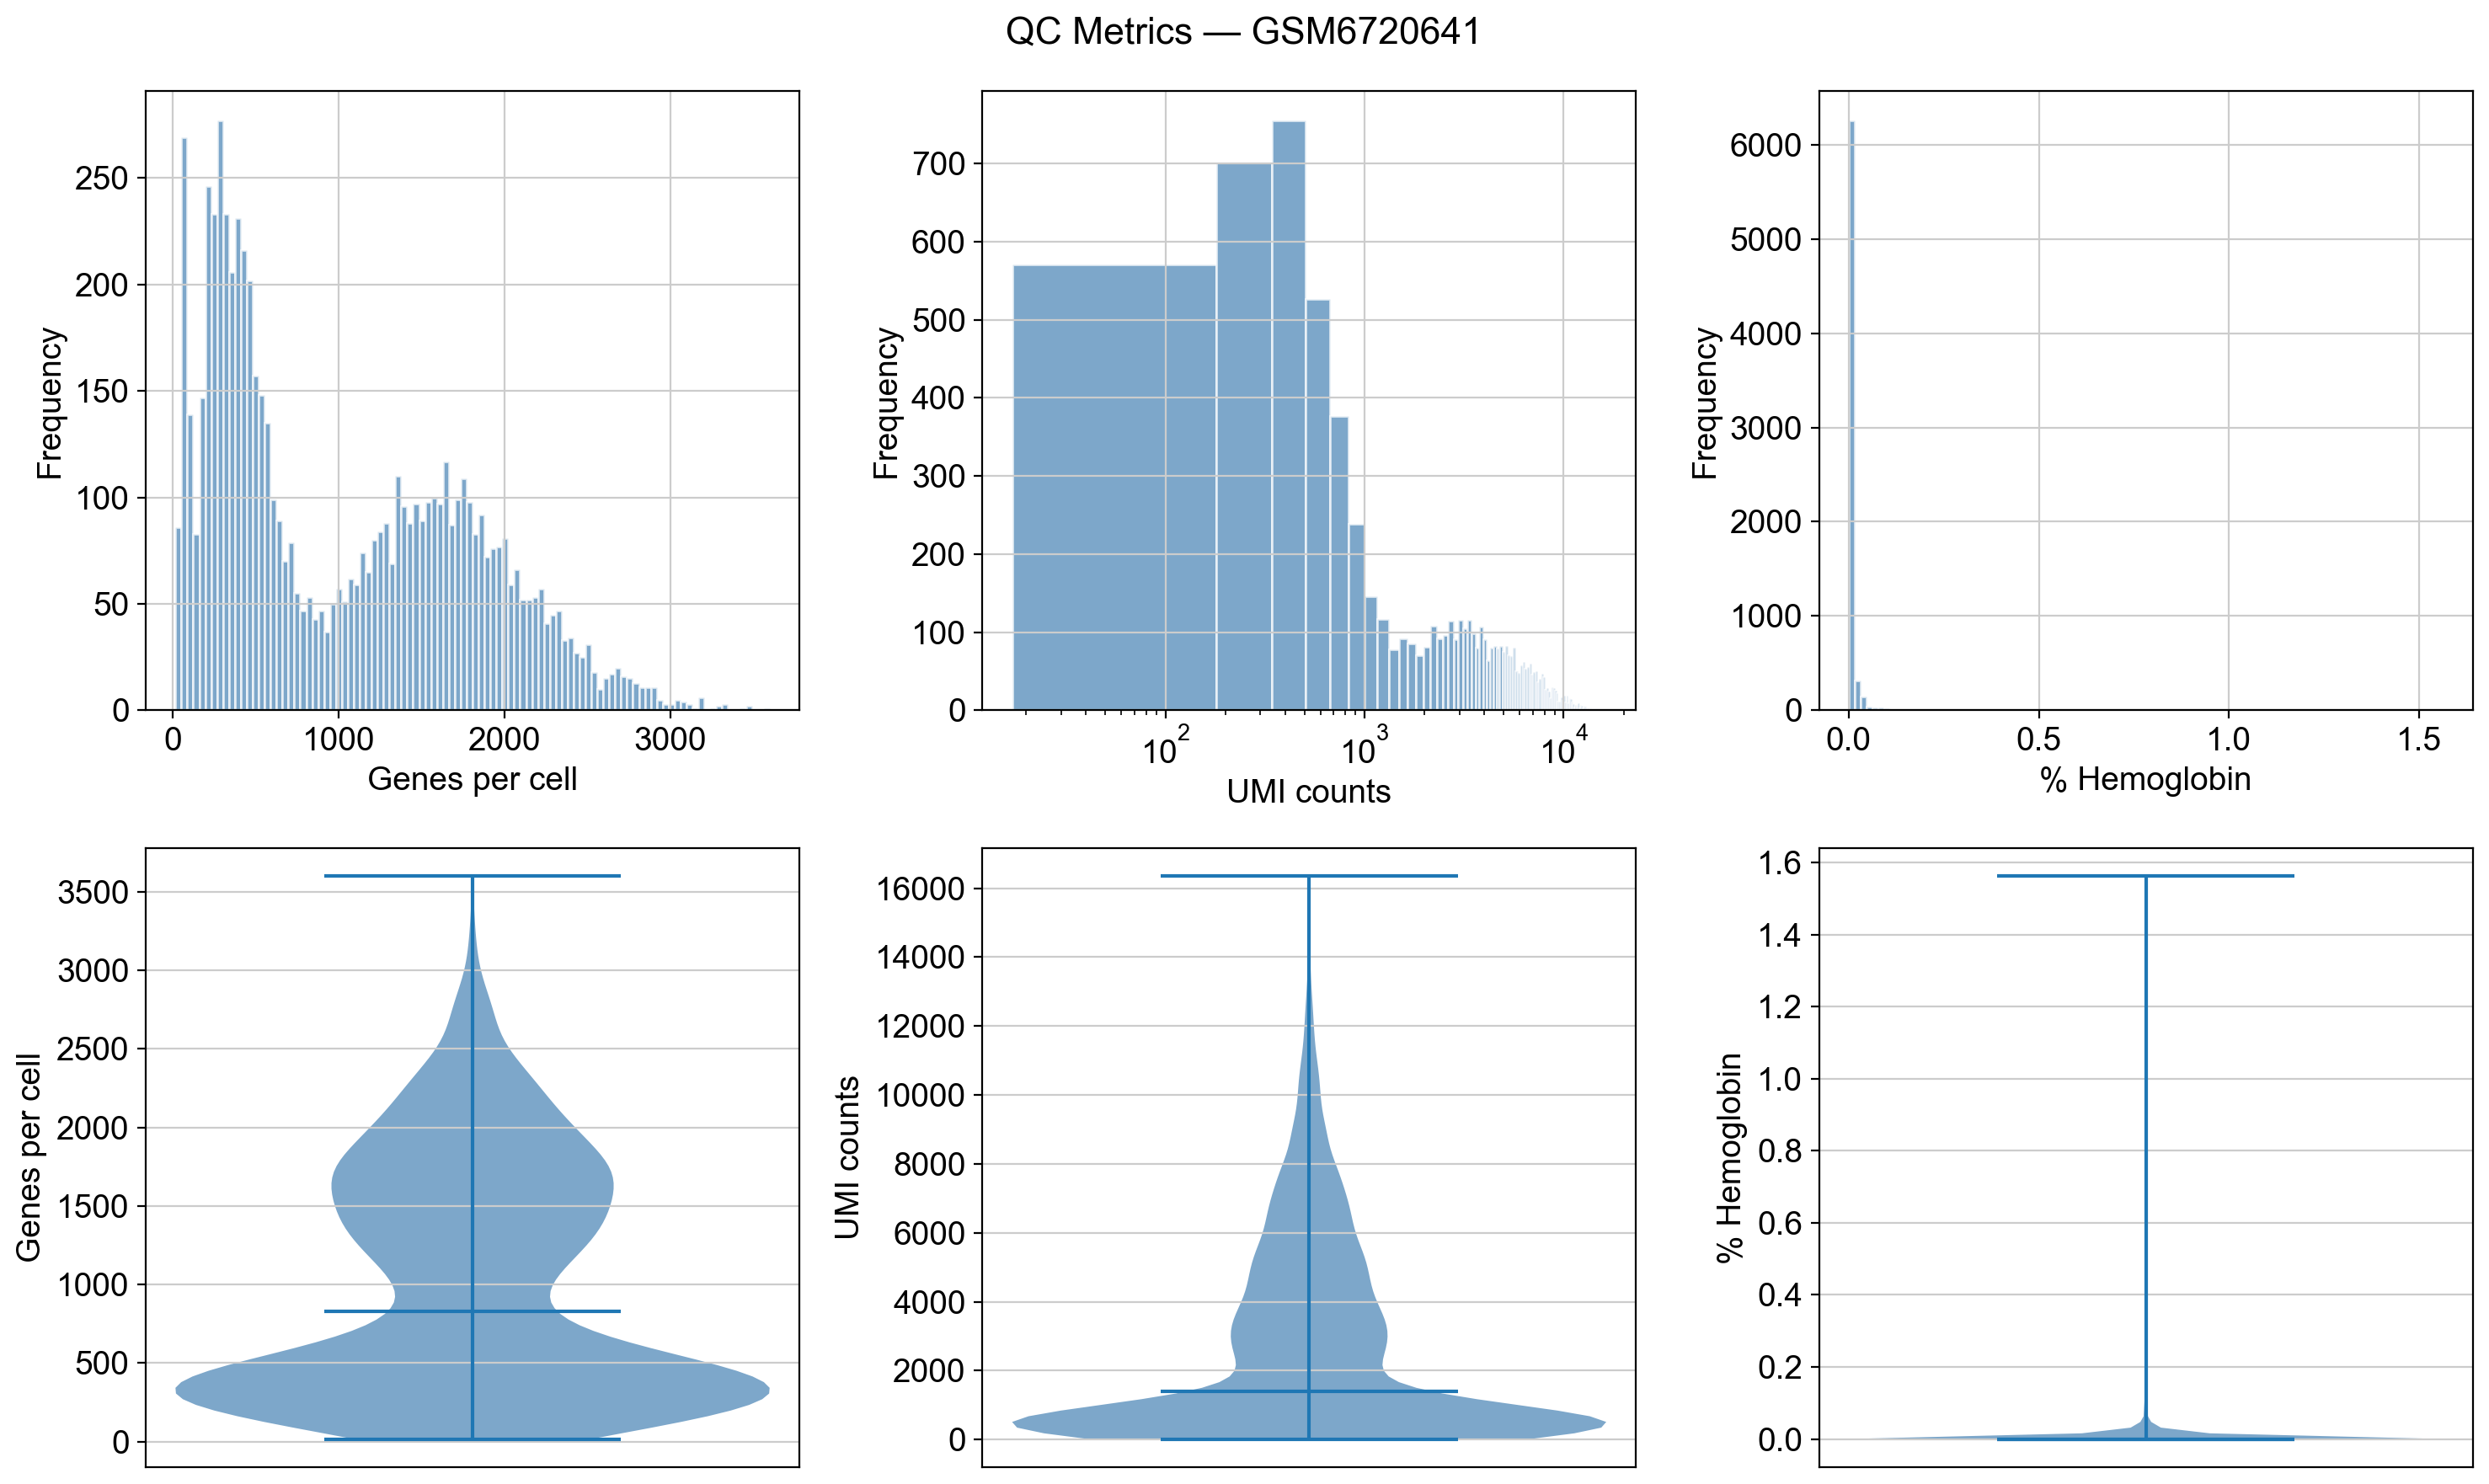

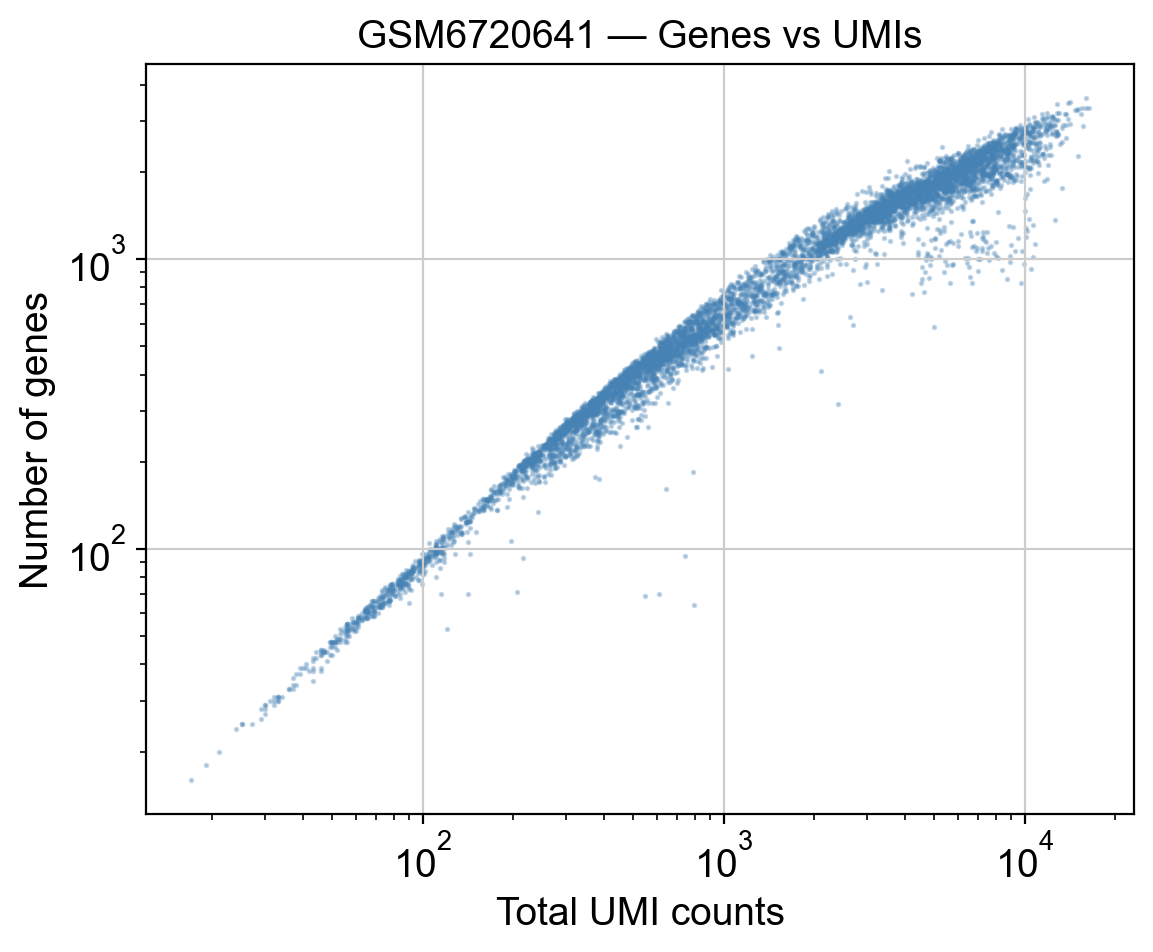


GSM6720641 Summary:
        n_genes_by_counts  total_counts  percent_hb
count             6951.00       6951.00     6951.00
mean              1025.44       2736.50        0.01
median             827.00       1410.00        0.00
std                763.28       2904.88        0.05
min                 16.00         17.00        0.00
max               3600.00      16355.00        1.56


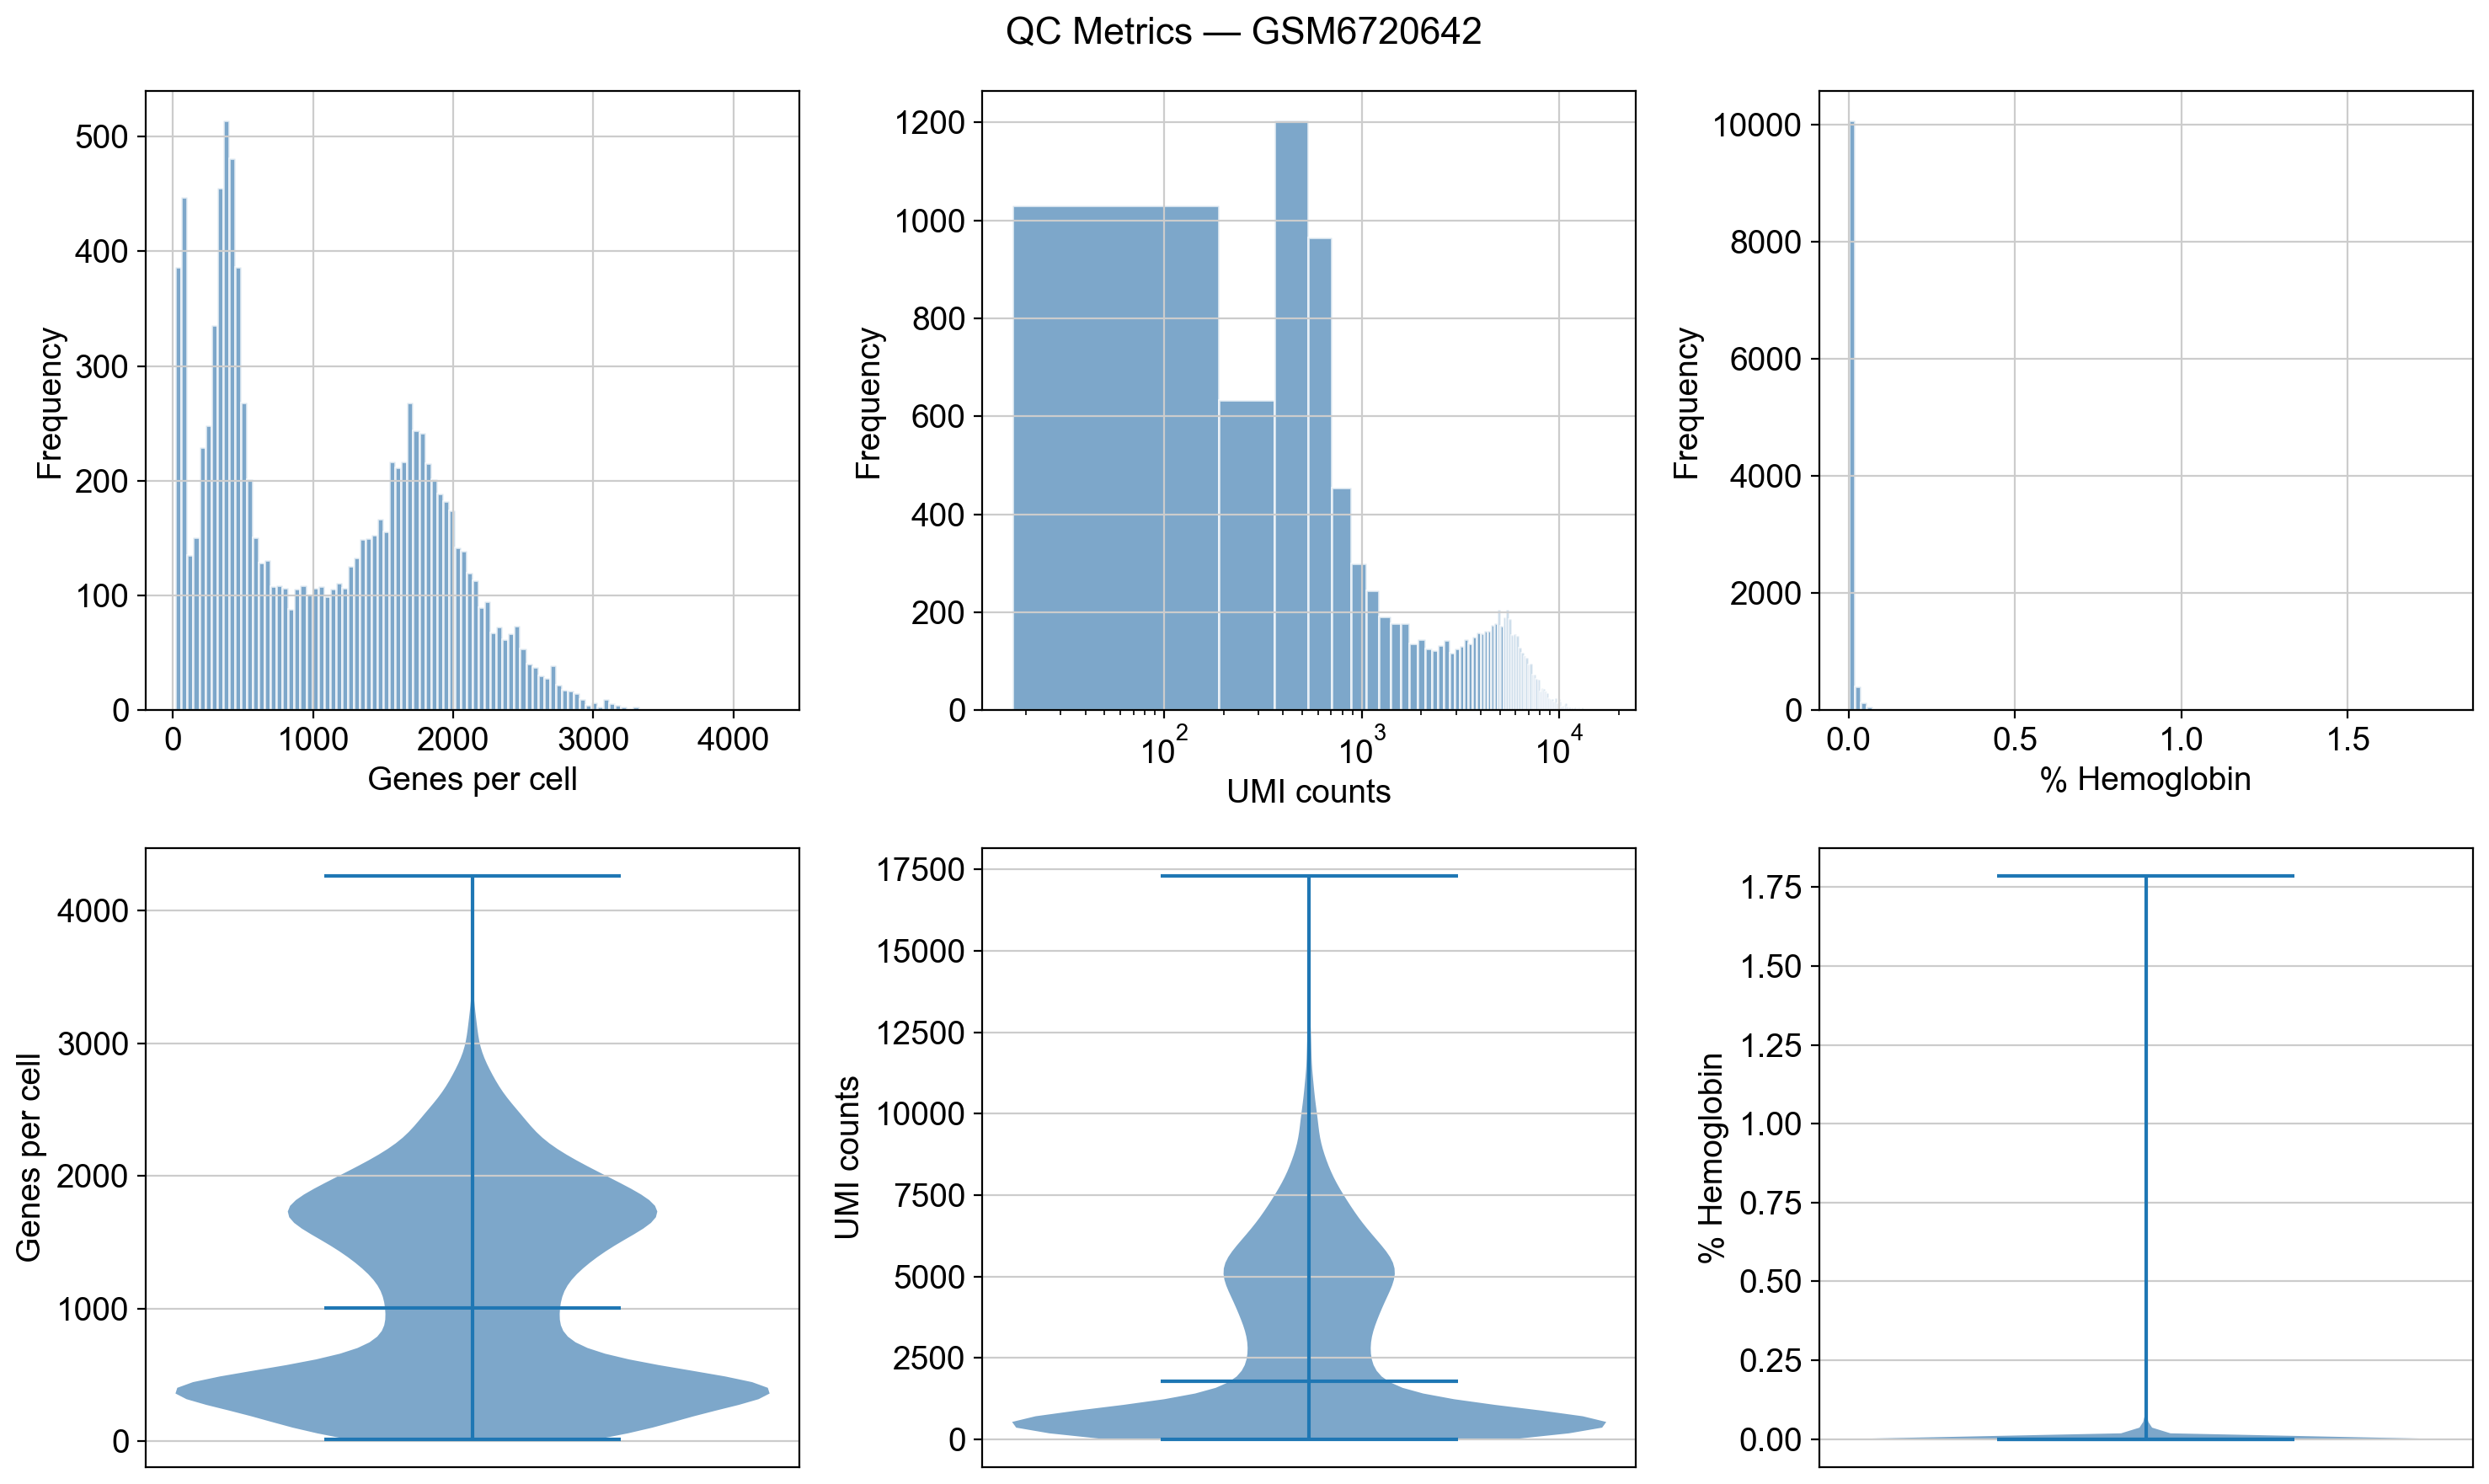

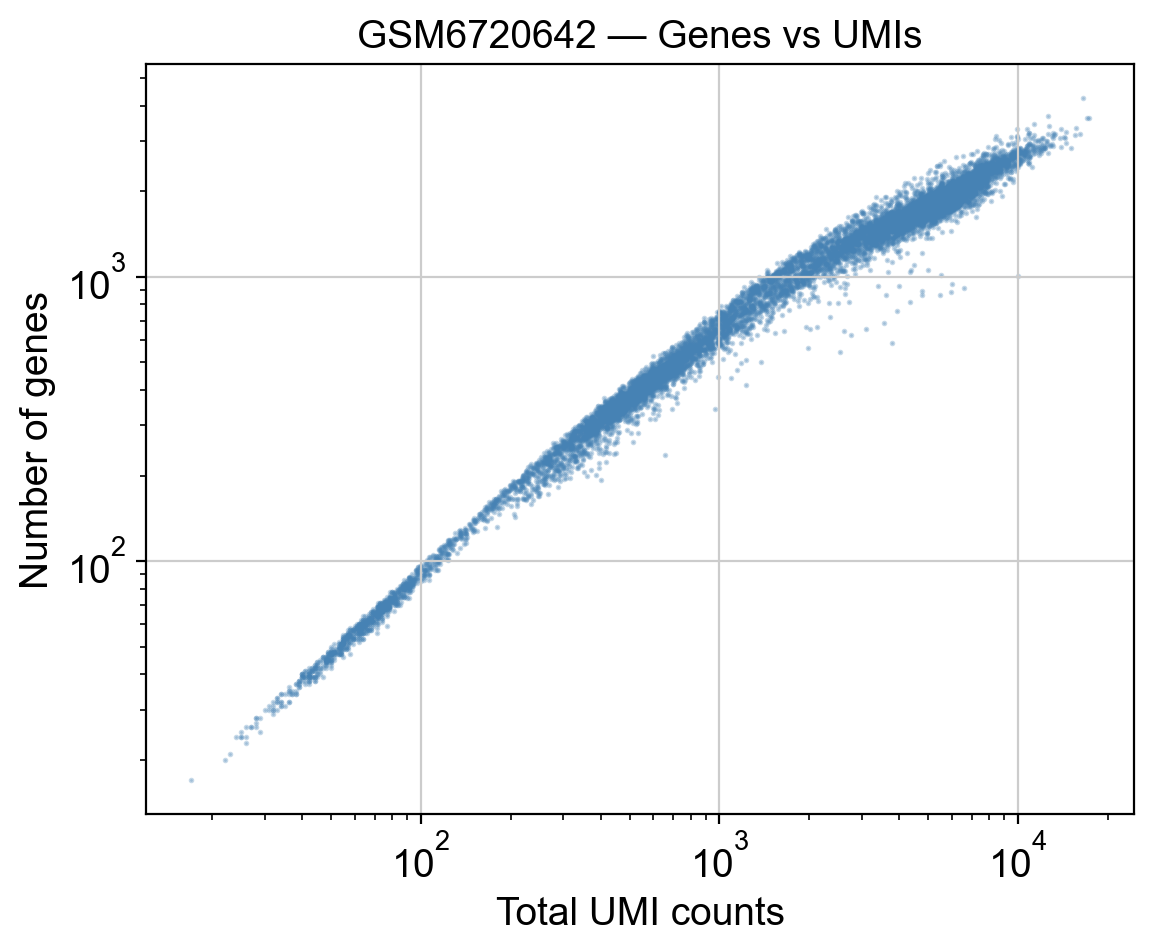


GSM6720642 Summary:
        n_genes_by_counts  total_counts  percent_hb
count            10813.00      10813.00    10813.00
mean              1088.71       2857.41        0.01
median            1007.00       1787.00        0.00
std                770.64       2738.96        0.04
min                 17.00         17.00        0.00
max               4260.00      17293.00        1.79


In [7]:
for sample_id, adata in adatas_raw.items():
    plot_qc_metrics(adata, sample_id)

## 4. Stage 1: Threshold-Based Filtering

No mito filtering since there are no mitochondrial genes. Filter on gene counts, UMI counts, and hemoglobin percentage only.

In [8]:
def find_knee_point(values, plot=False):
    """Find the knee point in a ranked curve using the maximum distance method."""
    sorted_values = np.sort(values)[::-1]
    log_values = np.log1p(sorted_values)
    log_rank = np.log1p(np.arange(len(sorted_values)))

    log_values_norm = (log_values - log_values.min()) / (log_values.max() - log_values.min() + 1e-10)
    log_rank_norm = (log_rank - log_rank.min()) / (log_rank.max() - log_rank.min() + 1e-10)

    x1, y1 = log_rank_norm[0], log_values_norm[0]
    x2, y2 = log_rank_norm[-1], log_values_norm[-1]

    distances = np.abs((y2-y1)*log_rank_norm - (x2-x1)*log_values_norm + x2*y1 - y2*x1) / \
                np.sqrt((y2-y1)**2 + (x2-x1)**2 + 1e-10)

    knee_idx = np.argmax(distances)
    knee_value = sorted_values[knee_idx]

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].plot(np.arange(len(sorted_values)), sorted_values, 'b-', alpha=0.5)
        axes[0].axhline(y=knee_value, color='r', linestyle='--', label=f'Knee: {knee_value:.0f}')
        axes[0].scatter([knee_idx], [knee_value], color='r', s=100, zorder=5)
        axes[0].set_xlabel('Cell rank'); axes[0].set_ylabel('Value'); axes[0].set_yscale('log')
        axes[0].legend(); axes[0].set_title('Knee Point Detection')
        axes[1].plot(log_rank, log_values, 'b-', alpha=0.5)
        axes[1].axhline(y=log_values[knee_idx], color='r', linestyle='--')
        axes[1].scatter([log_rank[knee_idx]], [log_values[knee_idx]], color='r', s=100, zorder=5)
        axes[1].set_xlabel('log(rank)'); axes[1].set_ylabel('log(value)')
        axes[1].set_title('log-log space')
        plt.tight_layout(); plt.show()

    return knee_value


def apply_stage1_filtering(adata, min_genes=200, min_counts=500, max_genes=None,
                           max_mito=None, max_hb=None, use_knee_point=False):
    """
    Stage 1: Basic cell filtering.
    max_mito defaults to None for this dataset (no mito genes).
    """
    n_cells_before = adata.n_obs
    has_mito = 'percent_mito' in adata.obs.columns and adata.obs['percent_mito'].sum() > 0

    if use_knee_point:
        min_genes = max(find_knee_point(adata.obs['n_genes_by_counts'].values, plot=True), 200)
        min_counts = max(find_knee_point(adata.obs['total_counts'].values, plot=True), 500)

    print(f"Stage 1 Thresholds:")
    print(f"  Min genes: {min_genes}, Min UMIs: {min_counts}")
    if max_genes: print(f"  Max genes: {max_genes}")
    if has_mito and max_mito is not None: print(f"  Max mito %: {max_mito}%")
    else: print(f"  Max mito %: SKIPPED (no mito genes)")
    if max_hb is not None: print(f"  Max HB %: {max_hb}%")

    # Distribution plots
    plot_cols = 2
    if max_hb is not None and 'percent_hb' in adata.obs.columns:
        plot_cols += 1
    fig, axes = plt.subplots(1, plot_cols, figsize=(5 * plot_cols, 4))

    axes[0].hist(adata.obs['n_genes_by_counts'], bins=100, alpha=0.7)
    axes[0].axvline(x=min_genes, color='r', linestyle='--', label=f'min={min_genes}')
    if max_genes: axes[0].axvline(x=max_genes, color='orange', linestyle='--', label=f'max={max_genes}')
    axes[0].set_xlabel('Genes per cell'); axes[0].legend()

    axes[1].hist(adata.obs['total_counts'], bins=100, alpha=0.7)
    axes[1].axvline(x=min_counts, color='r', linestyle='--', label=f'min={min_counts}')
    axes[1].set_xlabel('UMI counts'); axes[1].set_xscale('log'); axes[1].legend()

    if max_hb is not None and 'percent_hb' in adata.obs.columns:
        axes[2].hist(adata.obs['percent_hb'], bins=100, alpha=0.7)
        axes[2].axvline(x=max_hb, color='r', linestyle='--', label=f'max={max_hb}%')
        axes[2].set_xlabel('% Hemoglobin'); axes[2].legend()

    plt.tight_layout(); plt.show()

    # Apply filters
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_cells(adata, min_counts=min_counts)
    if max_genes:
        sc.pp.filter_cells(adata, max_genes=max_genes)

    n_mito_filtered = 0
    if has_mito and max_mito is not None:
        n_before = adata.n_obs
        adata = adata[adata.obs['percent_mito'] < max_mito].copy()
        n_mito_filtered = n_before - adata.n_obs

    n_hb_filtered = 0
    if max_hb is not None and 'percent_hb' in adata.obs.columns:
        n_before = adata.n_obs
        adata = adata[adata.obs['percent_hb'] < max_hb].copy()
        n_hb_filtered = n_before - adata.n_obs

    n_removed = n_cells_before - adata.n_obs
    pct_removed = (n_removed / n_cells_before) * 100 if n_cells_before > 0 else 0

    print(f"\nStage 1 Results:")
    print(f"  Cells before: {n_cells_before}")
    print(f"  Cells after: {adata.n_obs}")
    print(f"  Removed: {n_removed} ({pct_removed:.1f}%)")
    if n_hb_filtered: print(f"    - High HB: {n_hb_filtered}")

    return adata


STAGE 1: GSM6720641 (region=corpus)
Stage 1 Thresholds:
  Min genes: 200, Min UMIs: 500
  Max mito %: SKIPPED (no mito genes)
  Max HB %: 5%


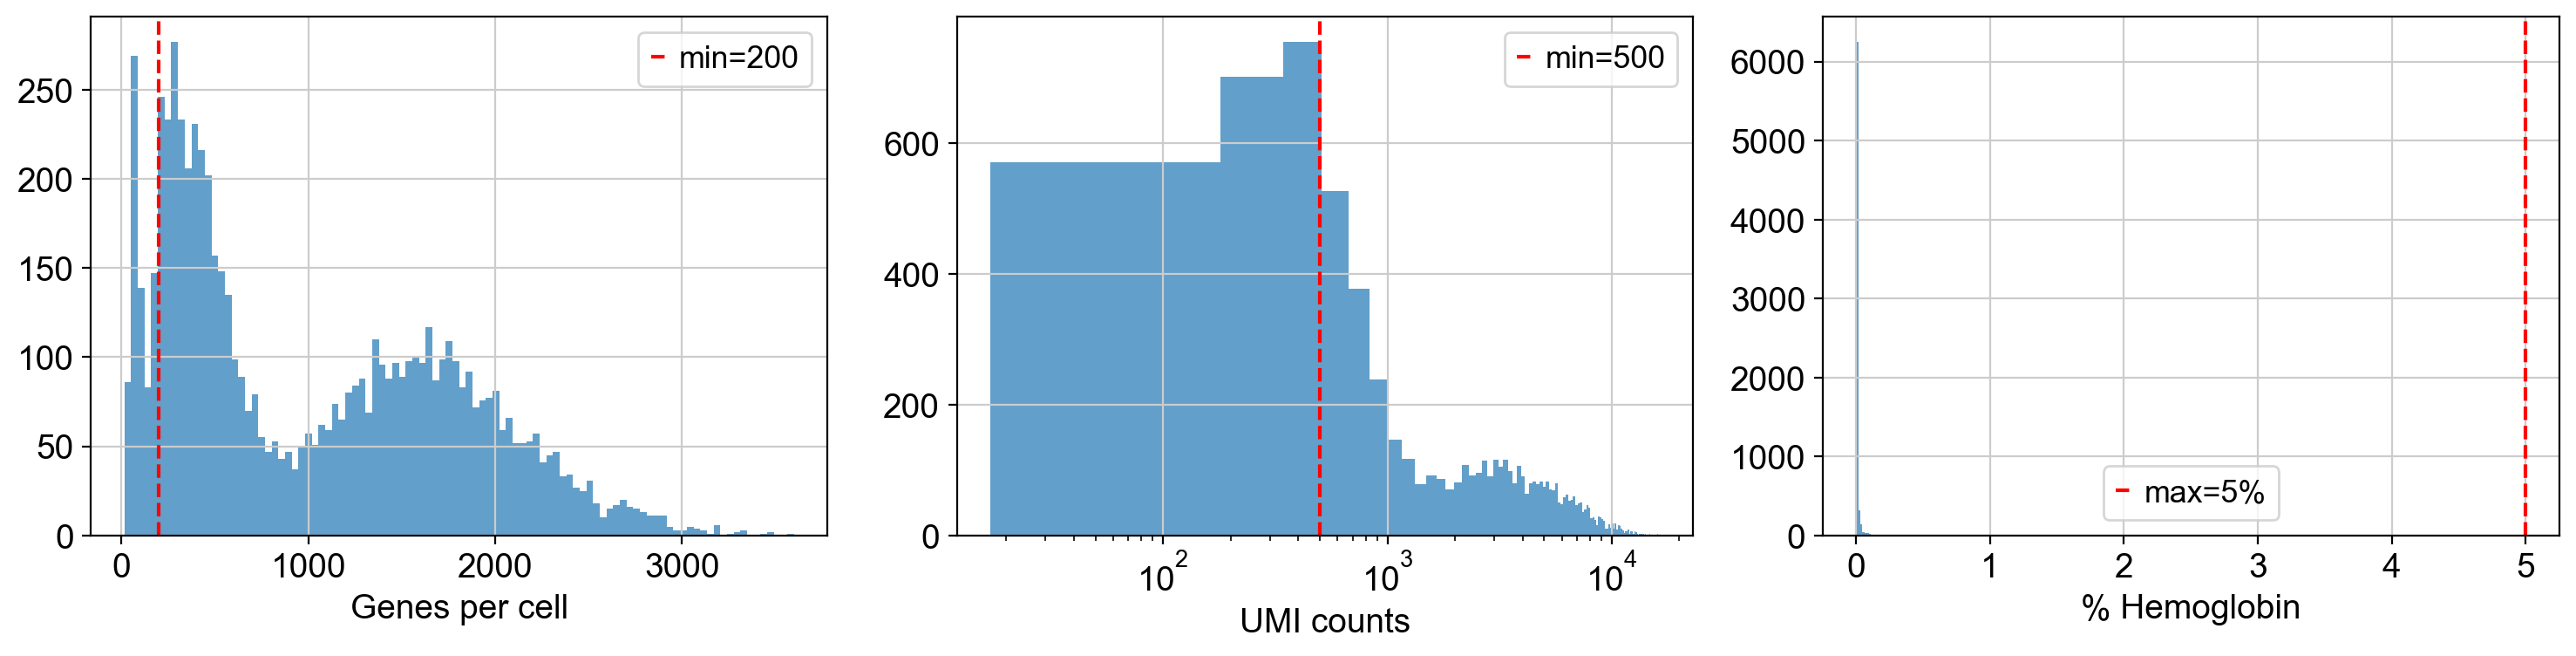

filtered out 753 cells that have less than 200 genes expressed


filtered out 1247 cells that have less than 500 counts



Stage 1 Results:
  Cells before: 6951
  Cells after: 4951
  Removed: 2000 (28.8%)

STAGE 1: GSM6720642 (region=antrum)


Stage 1 Thresholds:
  Min genes: 200, Min UMIs: 500
  Max mito %: SKIPPED (no mito genes)
  Max HB %: 5%


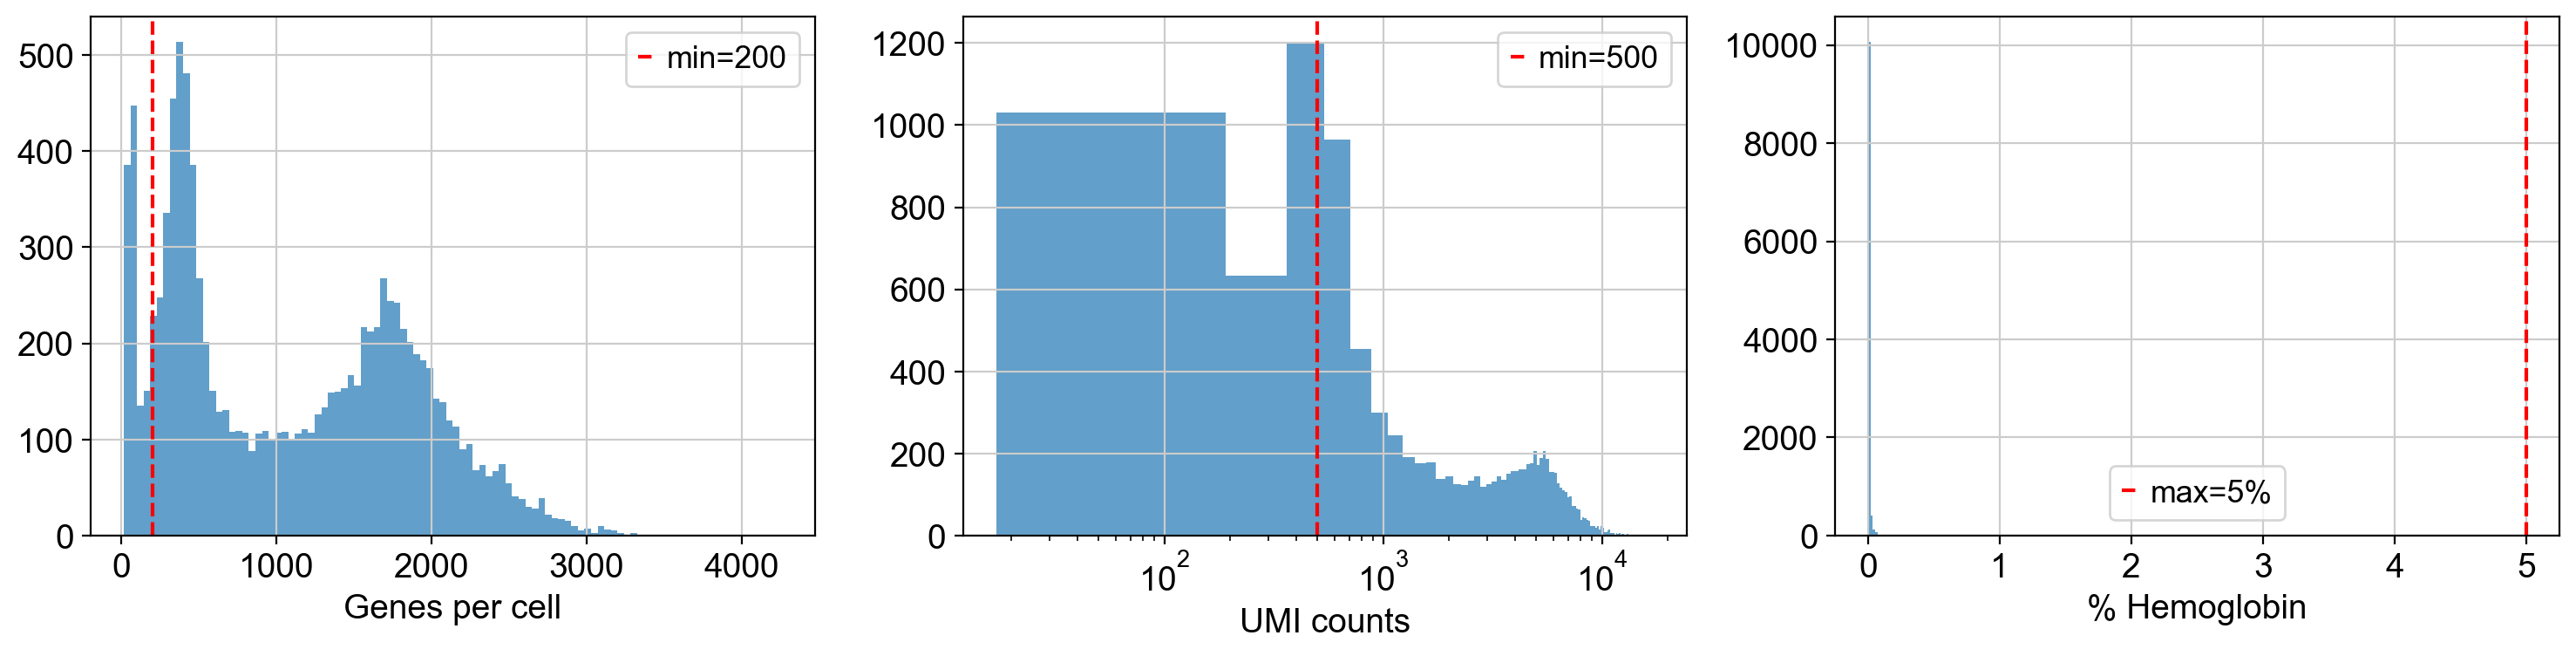

filtered out 1183 cells that have less than 200 genes expressed


filtered out 1385 cells that have less than 500 counts



Stage 1 Results:
  Cells before: 10813
  Cells after: 8245
  Removed: 2568 (23.7%)


In [9]:
adatas_stage1 = {}

MIN_GENES = 200
MIN_COUNTS = 500
MAX_GENES = None
MAX_MITO = None     # No mito genes in this dataset
MAX_HB = 5

for sample_id, adata in adatas_raw.items():
    print(f"\n{'='*60}")
    print(f"STAGE 1: {sample_id} (region={adata.obs['region'].iloc[0]})")
    print(f"{'='*60}")

    adata_filtered = apply_stage1_filtering(
        adata.copy(),
        min_genes=MIN_GENES, min_counts=MIN_COUNTS,
        max_genes=MAX_GENES, max_mito=MAX_MITO, max_hb=MAX_HB
    )
    adatas_stage1[sample_id] = adata_filtered

## 5. Stage 2: MAD-Based Outlier Filtering

MAD-based filtering on gene counts and UMI counts only (no mito/ribo metrics available).

In [10]:
def is_outlier(data, n_mads=3, direction='both'):
    """Detect outliers using MAD (Median Absolute Deviation)."""
    median = np.median(data)
    mad = median_abs_deviation(data)
    if direction == 'lower':
        return data < (median - n_mads * mad)
    elif direction == 'upper':
        return data > (median + n_mads * mad)
    else:
        return (data < (median - n_mads * mad)) | (data > (median + n_mads * mad))


def apply_stage2_filtering(adata, n_mads=3):
    """Stage 2: Remove outlier cells based on gene count and UMI count distributions."""
    n_cells_before = adata.n_obs

    outliers = pd.DataFrame(index=adata.obs.index)
    outliers['low_genes'] = is_outlier(adata.obs['n_genes_by_counts'], n_mads=n_mads, direction='both')
    outliers['low_counts'] = is_outlier(adata.obs['total_counts'], n_mads=n_mads, direction='both')

    is_outlier_cell = outliers.any(axis=1)

    print("Outlier Detection Results:")
    for col in outliers.columns:
        n_out = outliers[col].sum()
        print(f"  {col}: {n_out} cells ({n_out/n_cells_before*100:.1f}%)")

    adata = adata[~is_outlier_cell].copy()

    n_removed = n_cells_before - adata.n_obs
    pct_removed = (n_removed / n_cells_before) * 100 if n_cells_before > 0 else 0

    print(f"\nStage 2 Results:")
    print(f"  Cells before: {n_cells_before}")
    print(f"  Cells after: {adata.n_obs}")
    print(f"  Removed: {n_removed} ({pct_removed:.1f}%)")

    return adata

In [11]:
adatas_stage2 = {}

for sample_id, adata in adatas_stage1.items():
    print(f"\n{'='*60}")
    print(f"STAGE 2: {sample_id}")
    print(f"{'='*60}")

    adata_filtered = apply_stage2_filtering(adata.copy(), n_mads=5)
    adatas_stage2[sample_id] = adata_filtered


STAGE 2: GSM6720641
Outlier Detection Results:
  low_genes: 0 cells (0.0%)
  low_counts: 12 cells (0.2%)



Stage 2 Results:
  Cells before: 4951
  Cells after: 4939
  Removed: 12 (0.2%)

STAGE 2: GSM6720642
Outlier Detection Results:
  low_genes: 1 cells (0.0%)
  low_counts: 7 cells (0.1%)



Stage 2 Results:
  Cells before: 8245
  Cells after: 8238
  Removed: 7 (0.1%)


## 6. Doublet Detection

In [12]:
def detect_doublets_scrublet(adata, expected_doublet_rate=0.06, threshold=None):
    """Detect doublets using Scrublet."""
    print(f"Running Scrublet (expected rate: {expected_doublet_rate*100}%)")

    scrub = scr.Scrublet(adata.X, expected_doublet_rate=expected_doublet_rate)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(
        min_counts=2, min_cells=3, min_gene_variability_pctl=85, n_prin_comps=30
    )

    adata.obs['doublet_score'] = doublet_scores

    if threshold is not None:
        adata.obs['predicted_doublet'] = adata.obs['doublet_score'] > threshold
        final_threshold = threshold
        print(f"Using manual threshold: {threshold}")
    elif hasattr(scrub, 'threshold_') and scrub.threshold_ is not None:
        final_threshold = scrub.threshold_
        adata.obs['predicted_doublet'] = predicted_doublets
        print(f"Auto-detected threshold: {final_threshold:.3f}")
    else:
        final_threshold = 0.25
        adata.obs['predicted_doublet'] = adata.obs['doublet_score'] > final_threshold
        print(f"Auto-detection failed, using default threshold: {final_threshold}")

    if not hasattr(scrub, 'threshold_') or scrub.threshold_ is None:
        scrub.threshold_ = final_threshold

    n_doublets = adata.obs['predicted_doublet'].sum()
    print(f"Predicted doublets: {n_doublets} ({n_doublets/adata.n_obs*100:.1f}%)")

    scrub.plot_histogram()
    plt.show()

    return adata


DOUBLET DETECTION: GSM6720641
Running Scrublet (expected rate: 6.0%)


Preprocessing...


Simulating doublets...


Embedding transcriptomes using PCA...


Calculating doublet scores...


Automatically set threshold at doublet score = 0.59
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 1.8%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 6.6%
Elapsed time: 7.3 seconds
Auto-detected threshold: 0.593
Predicted doublets: 6 (0.1%)


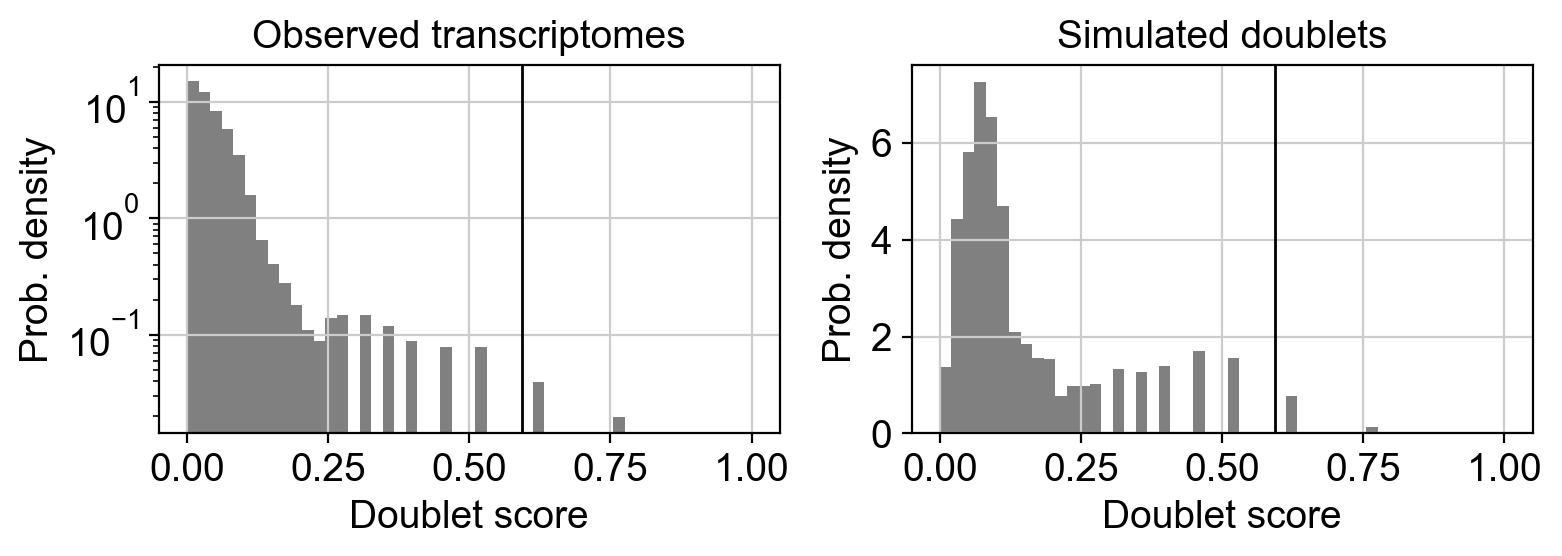


DOUBLET DETECTION: GSM6720642
Running Scrublet (expected rate: 6.0%)


Preprocessing...


Simulating doublets...


Embedding transcriptomes using PCA...


Calculating doublet scores...


Automatically set threshold at doublet score = 0.22
Detected doublet rate = 3.6%
Estimated detectable doublet fraction = 33.0%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 10.9%
Elapsed time: 17.2 seconds
Auto-detected threshold: 0.217
Predicted doublets: 295 (3.6%)


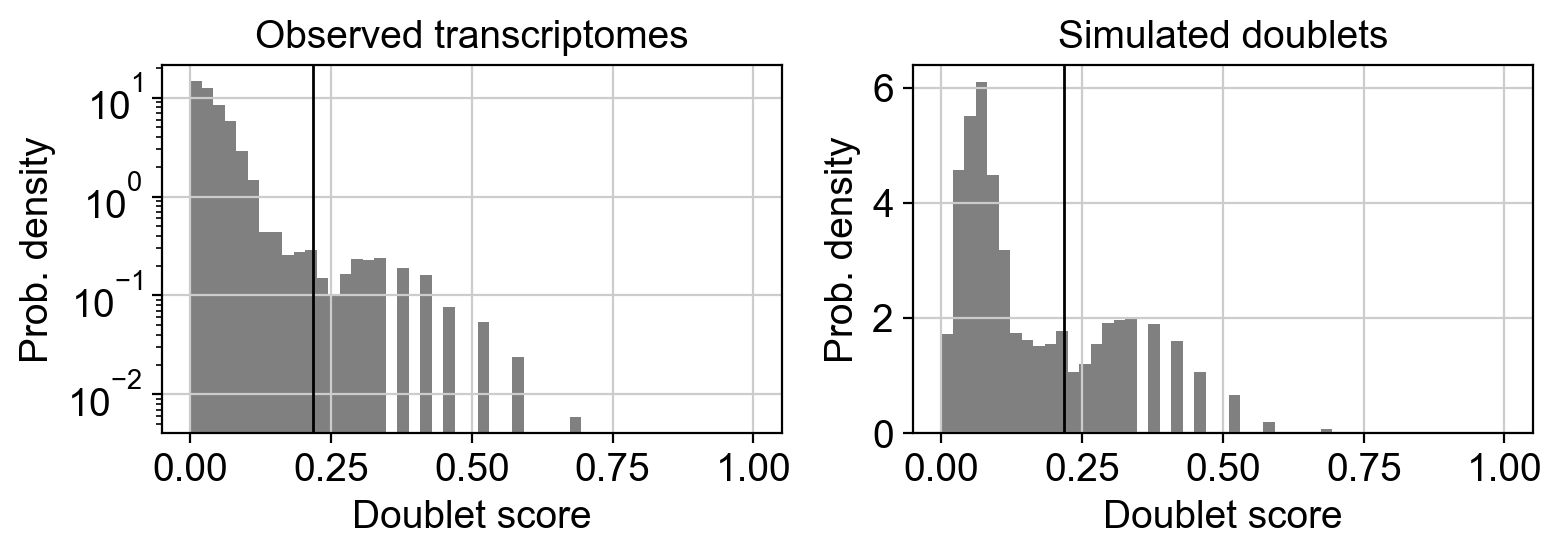

In [13]:
adatas_doublets = {}

for sample_id, adata in adatas_stage2.items():
    print(f"\n{'='*60}")
    print(f"DOUBLET DETECTION: {sample_id}")
    print(f"{'='*60}")

    adatas_doublets[sample_id] = detect_doublets_scrublet(adata.copy(), expected_doublet_rate=0.06)

In [14]:
adatas_filtered = {}

for sample_id, adata in adatas_doublets.items():
    n_before = adata.n_obs
    adata_singlets = adata[~adata.obs['predicted_doublet']].copy()
    n_removed = n_before - adata_singlets.n_obs
    print(f"{sample_id}: Removed {n_removed} doublets, kept {adata_singlets.n_obs} singlets")
    adatas_filtered[sample_id] = adata_singlets

GSM6720641: Removed 6 doublets, kept 4933 singlets
GSM6720642: Removed 295 doublets, kept 7943 singlets


## 6b. Check Sample Metadata and Cell Counts

In [15]:
MIN_CELLS_THRESHOLD = 100

print("="*70)
print("SAMPLE METADATA AND CELL COUNTS AFTER QC")
print("="*70)

metadata_list = []
for sample_id, adata in adatas_filtered.items():
    obs_cols = adata.obs.columns.tolist()
    metadata_list.append({
        'sample_id': sample_id,
        'n_cells': adata.n_obs,
        'n_genes': adata.n_vars,
        'region': adata.obs['region'].iloc[0] if 'region' in obs_cols else 'unknown',
        'condition': adata.obs['condition'].iloc[0] if 'condition' in obs_cols else 'unknown',
        'below_threshold': adata.n_obs < MIN_CELLS_THRESHOLD
    })

metadata_df = pd.DataFrame(metadata_list)
print(f"\nSample Metadata (threshold: {MIN_CELLS_THRESHOLD} cells):")
print("-"*70)
print(metadata_df[['sample_id', 'n_cells', 'region', 'condition', 'below_threshold']].to_string(index=False))

small_samples = metadata_df[metadata_df['below_threshold']]
if len(small_samples) > 0:
    print(f"\n{len(small_samples)} samples have fewer than {MIN_CELLS_THRESHOLD} cells:")
    for _, row in small_samples.iterrows():
        print(f"   - {row['sample_id']}: {row['n_cells']} cells ({row['region']})")
else:
    print(f"\nAll samples have >= {MIN_CELLS_THRESHOLD} cells")

SAMPLE METADATA AND CELL COUNTS AFTER QC

Sample Metadata (threshold: 100 cells):
----------------------------------------------------------------------
 sample_id  n_cells region condition  below_threshold
GSM6720641     4933 corpus        WT            False
GSM6720642     7943 antrum        WT            False

All samples have >= 100 cells


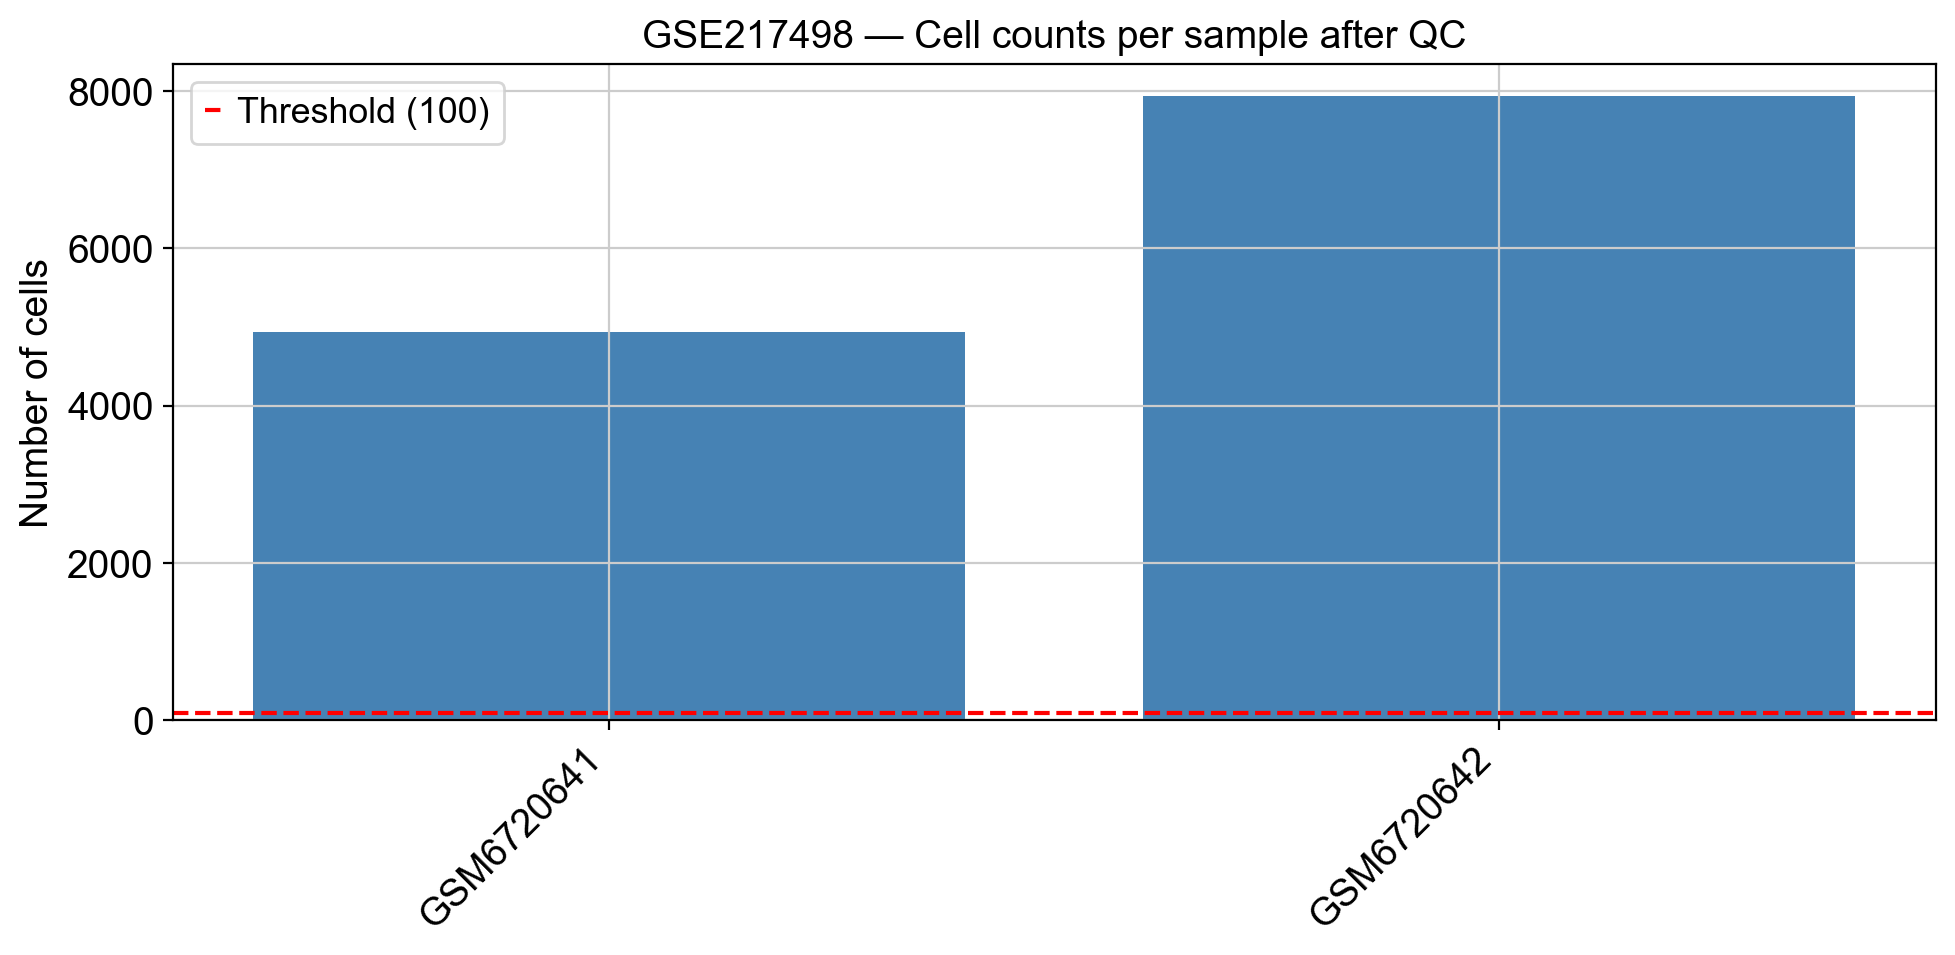

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['indianred' if below else 'steelblue' for below in metadata_df['below_threshold']]
ax.bar(range(len(metadata_df)), metadata_df['n_cells'], color=colors)
ax.axhline(y=MIN_CELLS_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({MIN_CELLS_THRESHOLD})')
ax.set_xticks(range(len(metadata_df)))
ax.set_xticklabels(metadata_df['sample_id'], rotation=45, ha='right')
ax.set_ylabel('Number of cells')
ax.set_title(f'{DATASET_ID} — Cell counts per sample after QC')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Visualize QC Metrics (After Filtering)

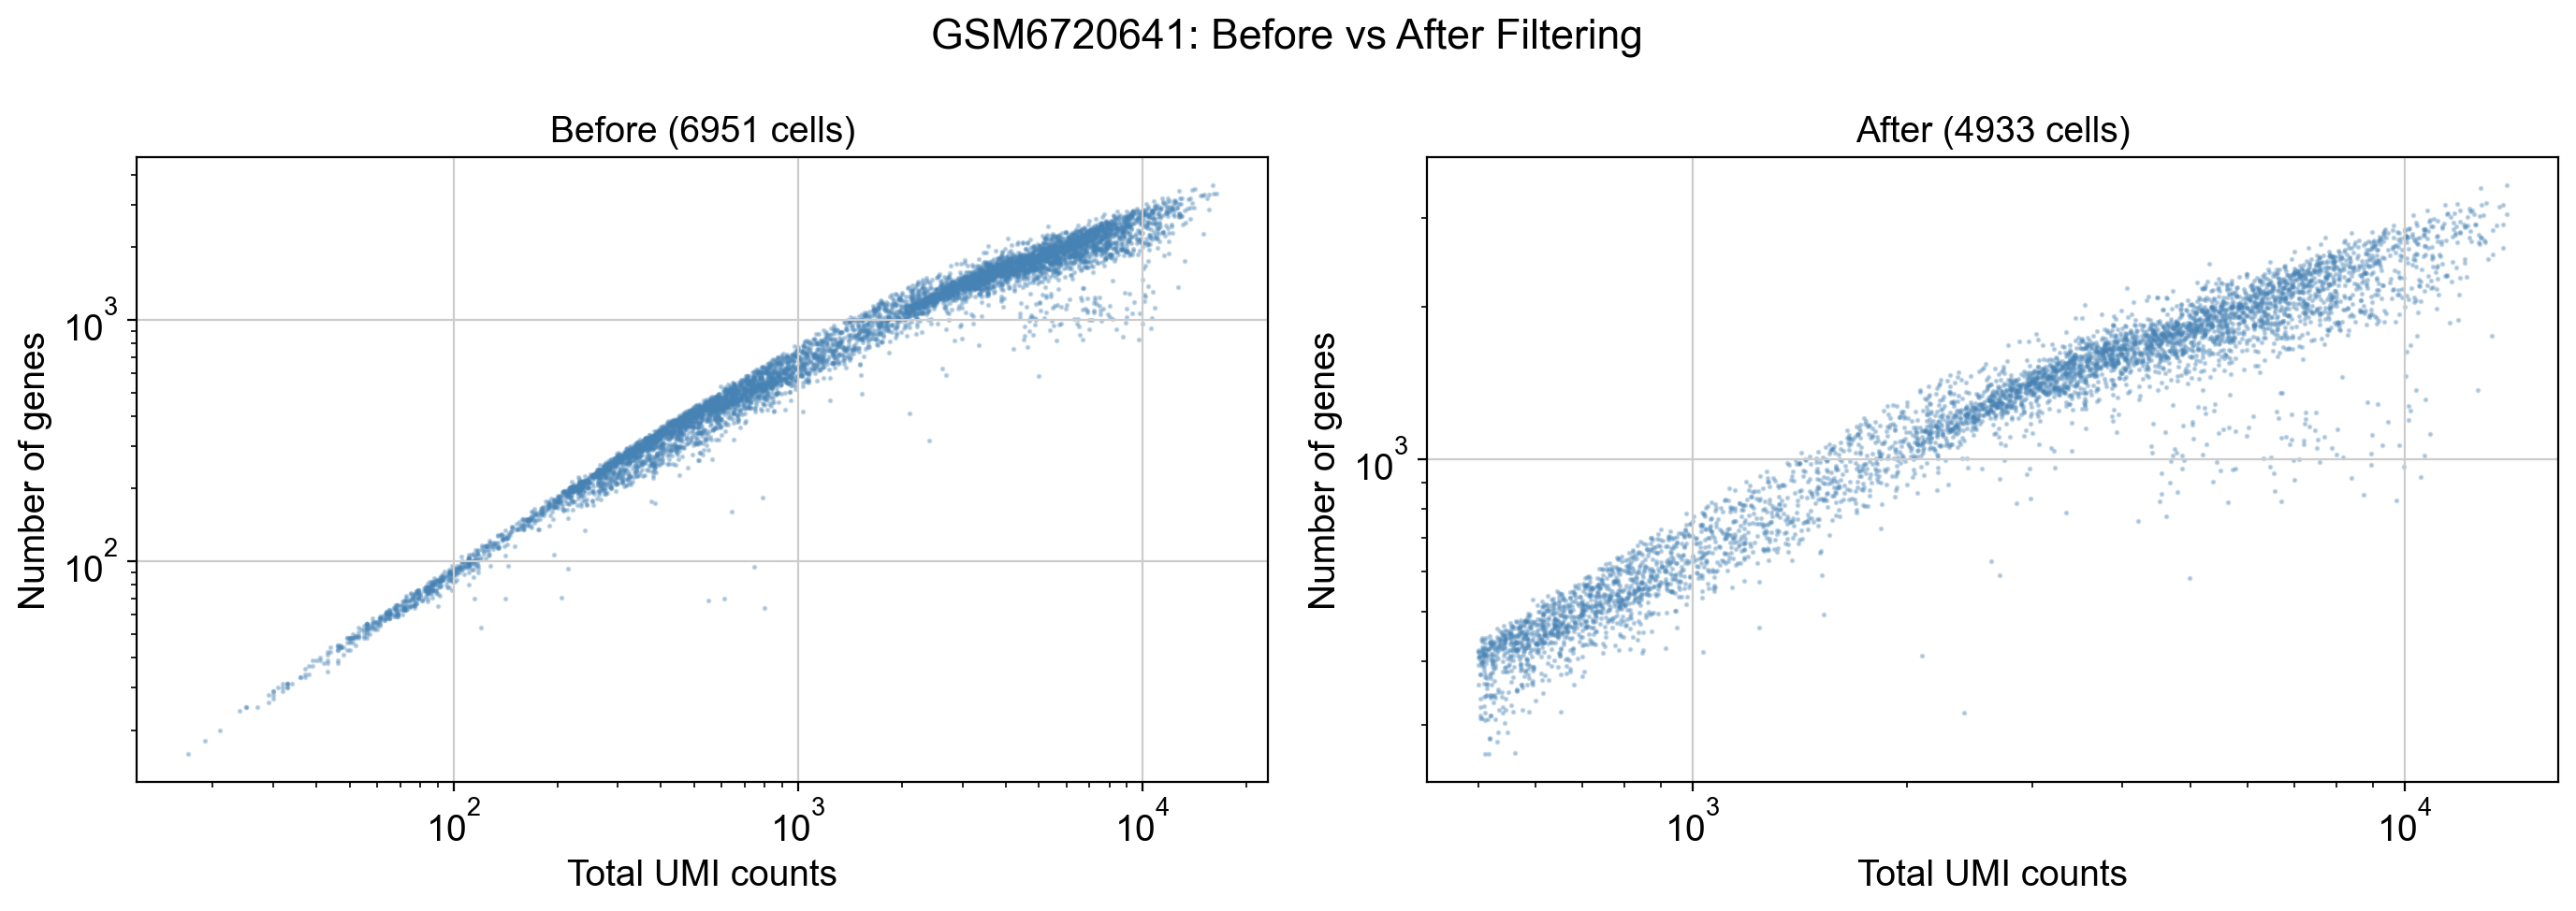

GSM6720641: Removed 2018 cells (29.0%)



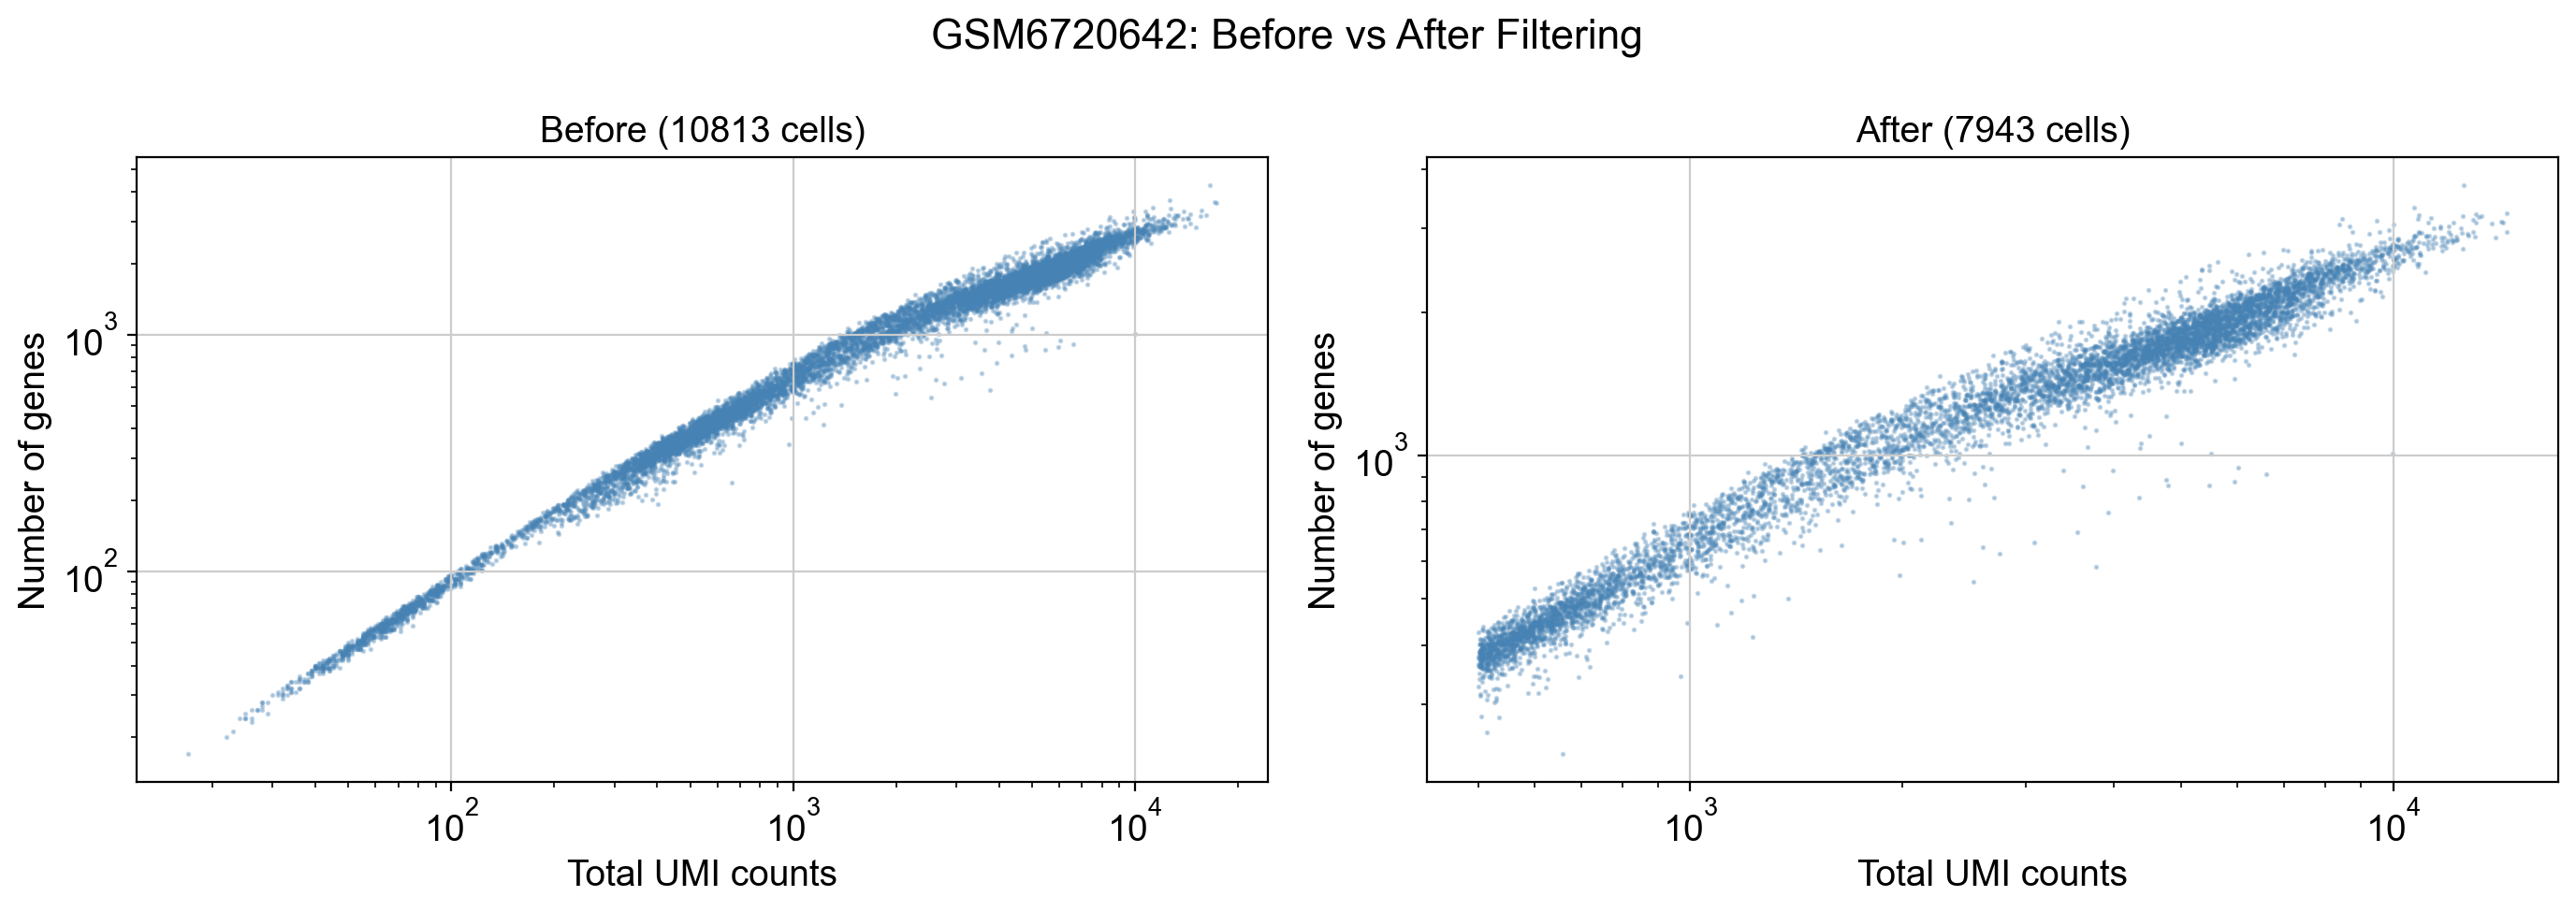

GSM6720642: Removed 2870 cells (26.5%)



In [17]:
for sample_id in adatas_raw.keys():
    adata_before = adatas_raw[sample_id]
    adata_after = adatas_filtered[sample_id]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{sample_id}: Before vs After Filtering', fontsize=16)

    axes[0].scatter(adata_before.obs['total_counts'], adata_before.obs['n_genes_by_counts'],
                    alpha=0.3, s=1, c='steelblue')
    axes[0].set_xlabel('Total UMI counts'); axes[0].set_ylabel('Number of genes')
    axes[0].set_title(f'Before ({adata_before.n_obs} cells)')
    axes[0].set_xscale('log'); axes[0].set_yscale('log')

    axes[1].scatter(adata_after.obs['total_counts'], adata_after.obs['n_genes_by_counts'],
                    alpha=0.3, s=1, c='steelblue')
    axes[1].set_xlabel('Total UMI counts'); axes[1].set_ylabel('Number of genes')
    axes[1].set_title(f'After ({adata_after.n_obs} cells)')
    axes[1].set_xscale('log'); axes[1].set_yscale('log')

    plt.tight_layout(); plt.show()

    n_removed = adata_before.n_obs - adata_after.n_obs
    pct_removed = (n_removed / adata_before.n_obs) * 100 if adata_before.n_obs > 0 else 0
    print(f"{sample_id}: Removed {n_removed} cells ({pct_removed:.1f}%)\n")

## 8. Concatenate Samples

In [18]:
def concatenate_samples(adata_dict, join='inner', batch_key='sample_id'):
    """Concatenate filtered samples with validation."""
    print("="*60)
    print("SAMPLE CONCATENATION")
    print("="*60)

    stats_list = []
    for sample_id, adata in adata_dict.items():
        stats = {
            'sample_id': sample_id,
            'n_cells': adata.n_obs,
            'n_genes': adata.n_vars,
            'median_genes': adata.obs['n_genes_by_counts'].median(),
            'median_umis': adata.obs['total_counts'].median(),
        }
        if 'percent_hb' in adata.obs.columns:
            stats['median_hb_pct'] = adata.obs['percent_hb'].median()
        stats_list.append(stats)

    stats_df = pd.DataFrame(stats_list)
    print("\nPer-sample statistics:")
    print(stats_df.to_string(index=False))

    # Gene overlap
    gene_sets = [set(a.var_names) for a in adata_dict.values()]
    common = set.intersection(*gene_sets)
    total = set.union(*gene_sets)
    print(f"\nGene overlap: {len(common)}/{len(total)} ({len(common)/len(total)*100:.1f}%)")

    # Concatenate
    adata_concat = sc.concat(
        list(adata_dict.values()),
        label=batch_key,
        keys=list(adata_dict.keys()),
        join=join,
        index_unique='-'
    )

    print(f"\nConcatenated: {adata_concat.n_obs} cells x {adata_concat.n_vars} genes")

    for sample_id, count in adata_concat.obs[batch_key].value_counts().items():
        orig = adata_dict[sample_id].n_obs
        status = 'OK' if count == orig else 'MISMATCH'
        print(f"  {sample_id}: {count} cells ({status})")

    return adata_concat, stats_df

In [19]:
adata_concat, sample_stats = concatenate_samples(adatas_filtered, join='inner', batch_key='sample_id')

SAMPLE CONCATENATION

Per-sample statistics:
 sample_id  n_cells  n_genes  median_genes  median_umis  median_hb_pct
GSM6720641     4933    19426        1375.0       3135.0            0.0
GSM6720642     7943    19426        1429.0       3360.0            0.0

Gene overlap: 19426/19426 (100.0%)

Concatenated: 12876 cells x 19426 genes
  GSM6720642: 7943 cells (OK)
  GSM6720641: 4933 cells (OK)


### Visualize Sample Distribution After Concatenation

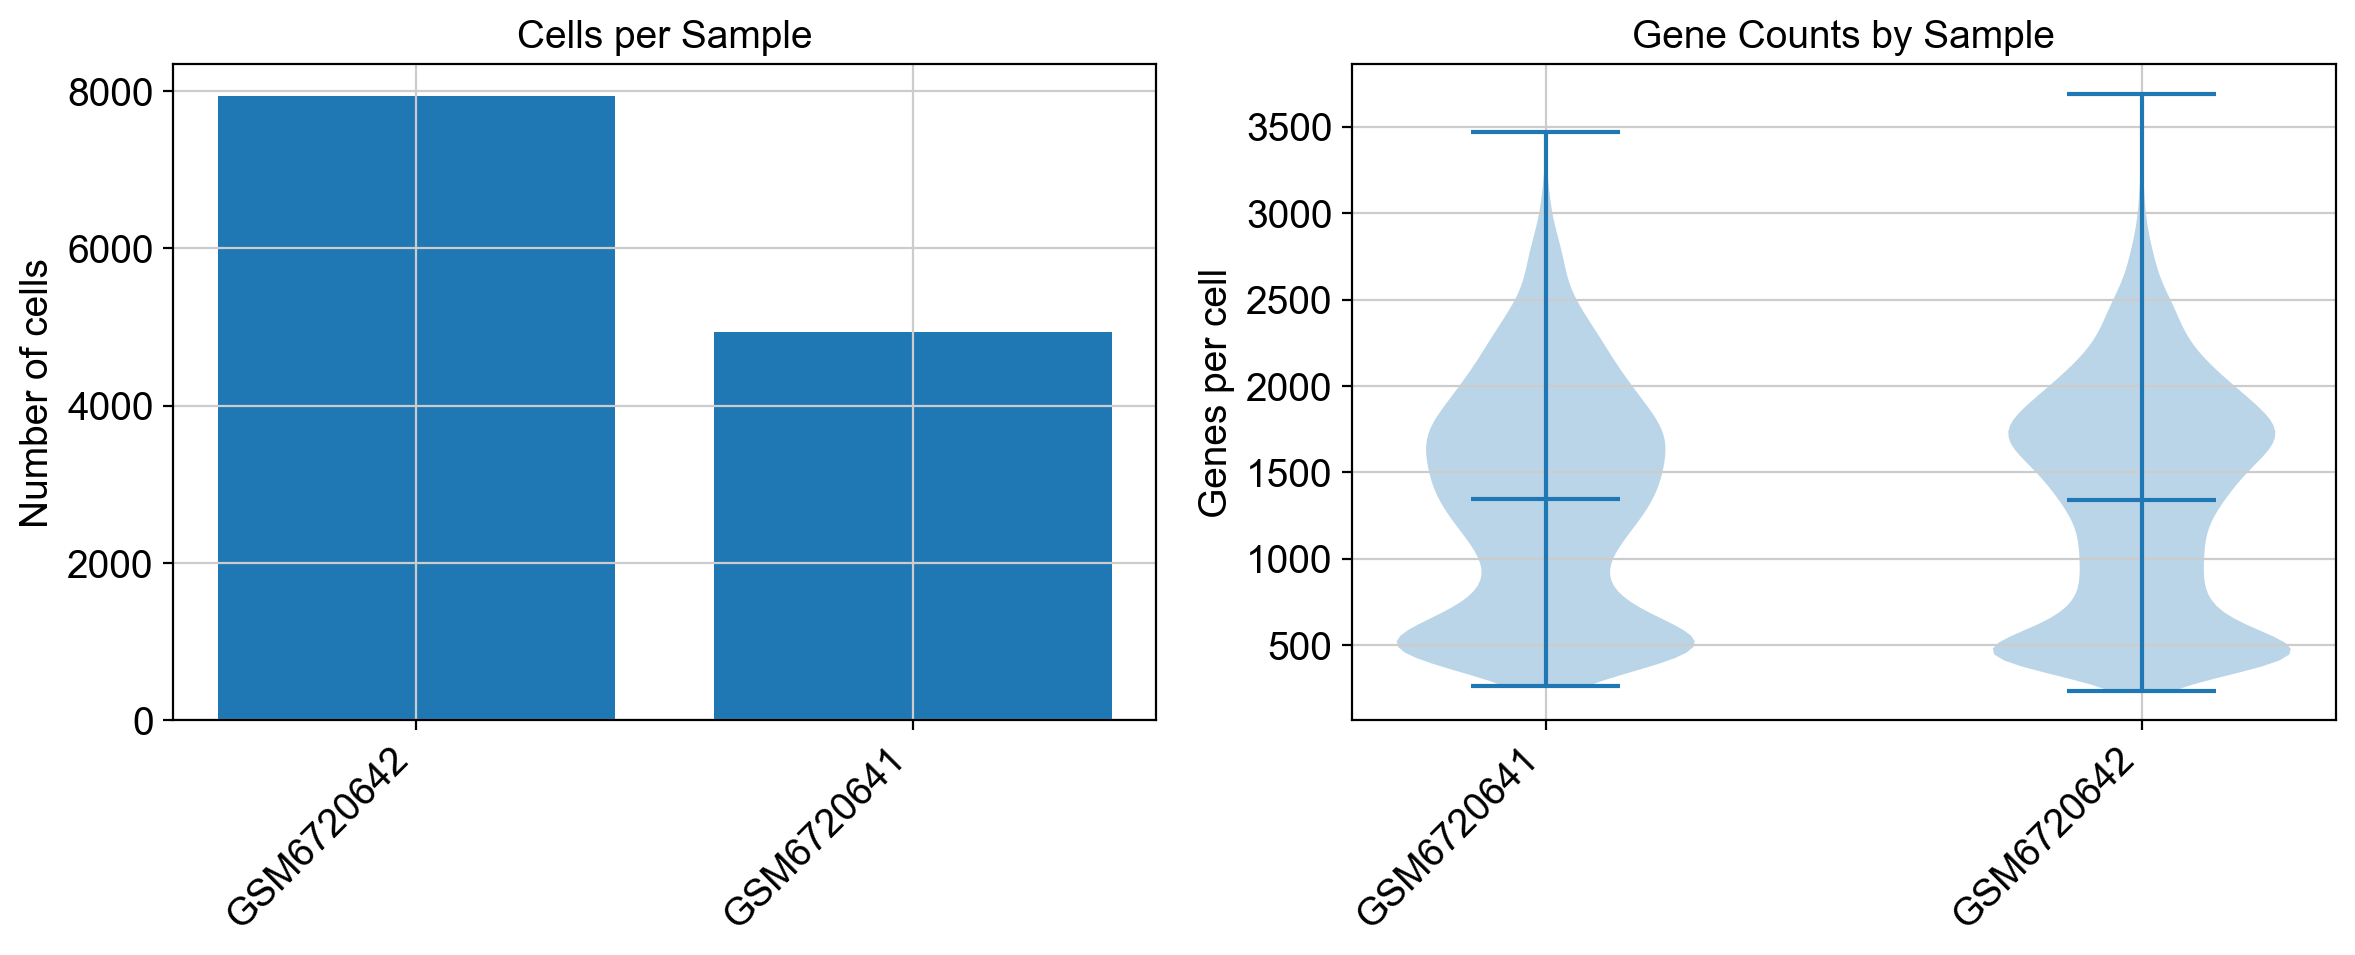

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_counts = adata_concat.obs['sample_id'].value_counts()
axes[0].bar(range(len(sample_counts)), sample_counts.values)
axes[0].set_xticks(range(len(sample_counts)))
axes[0].set_xticklabels(sample_counts.index, rotation=45, ha='right')
axes[0].set_ylabel('Number of cells')
axes[0].set_title('Cells per Sample')

sample_ids = adata_concat.obs['sample_id'].unique()
positions = range(len(sample_ids))
violin_genes = [adata_concat[adata_concat.obs['sample_id'] == sid].obs['n_genes_by_counts'].values for sid in sample_ids]
axes[1].violinplot(violin_genes, positions=positions, showmeans=True)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(sample_ids, rotation=45, ha='right')
axes[1].set_ylabel('Genes per cell')
axes[1].set_title('Gene Counts by Sample')

plt.tight_layout()
plt.show()

## 9. Filter Genes

Remove genes detected in very few cells.

In [21]:
print(f"Genes before filtering: {adata_concat.n_vars}")
sc.pp.filter_genes(adata_concat, min_cells=3)
print(f"Genes after filtering: {adata_concat.n_vars}")

Genes before filtering: 19426
filtered out 7787 genes that are detected in less than 3 cells


Genes after filtering: 11639


## 10. Save Filtered Data

In [22]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_file = f'{OUTPUT_DIR}/{DATASET_ID}_filtered.h5ad'
adata_concat.write_h5ad(output_file)
print(f"Saved: {output_file}")
print(f"  {adata_concat.n_obs} cells x {adata_concat.n_vars} genes")

stats_file = f'{OUTPUT_DIR}/{DATASET_ID}_qc_statistics.csv'
sample_stats.to_csv(stats_file, index=False)
print(f"Saved statistics: {stats_file}")

Saved: ../data/processed/GSE217498_filtered.h5ad
  12876 cells x 11639 genes
Saved statistics: ../data/processed/GSE217498_qc_statistics.csv


## 11. Summary Report

In [23]:
print("="*60)
print("QC FILTERING SUMMARY — GSE217498")
print("="*60)

total_raw = sum(a.n_obs for a in adatas_raw.values())
total_filtered = adata_concat.n_obs
pct_retained = (total_filtered / total_raw) * 100

print(f"\nNote: No mito/ribo genes in this dataset (pre-removed by depositors)")
print(f"QC was performed on gene counts, UMI counts, and hemoglobin % only.")

print(f"\nOverall:")
print(f"  Starting cells: {total_raw}")
print(f"  Final cells: {total_filtered}")
print(f"  Retained: {pct_retained:.1f}%")

print(f"\nFinal QC Metrics:")
print(f"  Median genes/cell: {adata_concat.obs['n_genes_by_counts'].median():.0f}")
print(f"  Median UMIs/cell: {adata_concat.obs['total_counts'].median():.0f}")
if 'percent_hb' in adata_concat.obs.columns:
    print(f"  Median HB %: {adata_concat.obs['percent_hb'].median():.2f}%")

print(f"\nSamples by region:")
for region in adata_concat.obs['region'].unique():
    mask = adata_concat.obs['region'] == region
    n_cells = mask.sum()
    n_samples = adata_concat.obs.loc[mask, 'sample_id'].nunique()
    print(f"  {region}: {n_cells} cells across {n_samples} samples")

print(f"\nOutput: {output_file}")

QC FILTERING SUMMARY — GSE217498

Note: No mito/ribo genes in this dataset (pre-removed by depositors)
QC was performed on gene counts, UMI counts, and hemoglobin % only.

Overall:
  Starting cells: 17764
  Final cells: 12876
  Retained: 72.5%

Final QC Metrics:
  Median genes/cell: 1404
  Median UMIs/cell: 3258
  Median HB %: 0.00%

Samples by region:
  corpus: 4933 cells across 1 samples
  antrum: 7943 cells across 1 samples

Output: ../data/processed/GSE217498_filtered.h5ad
